# MEG Source Space Analysis - Complete Example

This notebook demonstrates how to perform source space analysis on MEG data, including individual-level source reconstruction and group-level statistics.

## Contents
1. Setup and Configuration
2. Prerequisites - Coregistration and FreeSurfer
3. Single Subject Source Analysis
4. Batch Processing Multiple Subjects
5. Group-Level Source Statistics
6. Custom Analysis with Step-by-Step Control
7. Visualization and Results

**Author:** Nikita Otstavnov, 2023 (refactored 2026)  
**Last Updated:** March 18, 2026

## Setup and Imports

Import all necessary modules for source space analysis.

In [24]:
import os
import yaml
import numpy as np
import mne
import matplotlib.pyplot as plt

# Import custom analysis functions
from source_space_individual_analysis import run_source_analysis, load_config
from STWM_functions_core import (
    creating_source_space_object,
    creating_forward_model,
    creating_source_estimate_object,
    source_estimate_morphing_to_average,
    source_estimate_visualization,
    source_estimate_visualization_morph,
    stc_merger,
    source_estimate_average_visual_checher,
    statistical_inference,
    stat_visualization
)

print("✓ All modules imported successfully")
print(f"MNE version: {mne.__version__}")

# Set matplotlib backend
# For interactive 3D brain visualization, use 'qt' (requires PyQt5)
# For inline plotting in notebooks, use 'inline' or 'widget' (requires ipympl)
%matplotlib inline
# Uncomment the line below for interactive Qt plotting (PyQt5 required):
# %matplotlib qt

✓ All modules imported successfully
MNE version: 1.11.0


## Load Configuration

Load the configuration file for source space analysis.

In [25]:
# Load configuration
config_path = 'config.yaml'

try:
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print("✓ Configuration loaded successfully!")
except FileNotFoundError:
    print("⚠ Warning: config.yaml not found. Creating template configuration...")
    config = {
        'paths': {
            'data_folder': '/path/to/your/data',
            'output_folder': '/path/to/output',
            'subjects_dir': '/path/to/freesurfer/subjects'
        },
        'subject': {
            'name': 'S1',
            'file_name': 'S1_preprocessed-raw.fif'
        },
        'conditions': {
            'condition_1': {'name': 'Spatial', 'event_id': 26},
            'condition_2': {'name': 'Temporal', 'event_id': 46},
            'baseline': {'name': 'Baseline', 'event_id': None}
        },
        'source_space': {
            'spacing': 'ico4',
            'surfaces': 'white',
            'orientation': 'coronal'
        },
        'forward_model': {
            'conductivity': [0.3],
            'ico': 5,
            'mindist': 5.0,
            'surfaces': 'white',
            'coord_frame': 'mri'
        },
        'source_estimate': {
            'freq_min': 8,
            'freq_max': 12,
            'orientation': 'fix',
            'surf_ori': True,
            'force_fixed': True,
            'reg': 0.05,
            'depth': 1.0,
            'method': 'dSPM'
        },
        'visualization': {
            'hemi': 'both',
            'surface': 'inflated',
            'views': ['dorsal', 'lateral', 'medial', 'ventral']
        },
        'processing': {
            'n_jobs': 4
        },
        'statistics': {
            'num_subjects': 3,
            'p_threshold': 0.01,
            'n_permutations': 2000,
            'alpha_level': 0.05,
            'tstep': 1
        }
    }
    print("  Please edit the configuration with your paths and parameters!")

print(f"\nSource space configuration:")
print(f"  Data folder: {config['paths']['data_folder']}")
print(f"  FreeSurfer subjects_dir: {config['paths']['subjects_dir']}")
print(f"  Subject: {config['subject']['subject_name']}")
print(f"  Frequency band: {config['source_estimate']['freq_min']}-{config['source_estimate']['freq_max']} Hz")
print(f"  Spacing: {config['source_space']['spacing']}")

✓ Configuration loaded successfully!

Source space configuration:
  Data folder: /Users/administrator/__PC_HSE/Results/Yulia K/Data/meg
  FreeSurfer subjects_dir: /Users/administrator/__PC_HSE/Results/Yulia K/Data/freesurfer/subjects
  Subject: S1
  Frequency band: 8-12 Hz
  Spacing: ico4


---
## Prerequisites: Coregistration and FreeSurfer

Before running source analysis, ensure you have completed the following steps:

### 1. FreeSurfer Reconstruction

Run FreeSurfer on your subject's anatomical MRI:
```bash
recon-all -s S1 -i /path/to/T1.nii -all
```

This creates cortical surface reconstructions and takes ~6-12 hours.

### 2. Coregistration

Align MEG sensors with the MRI using MNE's coregistration GUI:

In [26]:
# Uncomment to run coregistration GUI
# subject_name = config['subject']['name']
# subjects_dir = config['paths']['subjects_dir']
# 
# mne.gui.coregistration(subject=subject_name, subjects_dir=subjects_dir)

print("Instructions for coregistration:")
print("1. Load your subject's anatomical data")
print("2. Load the MEG data file")
print("3. Fit fiducials (nasion, LPA, RPA)")
print("4. Use ICP fit to align head shape digitization")
print("5. Save transformation as: {subject}-trans.fif")
print("\n⚠ The trans.fif file must be in your data folder!")

Instructions for coregistration:
1. Load your subject's anatomical data
2. Load the MEG data file
3. Fit fiducials (nasion, LPA, RPA)
4. Use ICP fit to align head shape digitization
5. Save transformation as: {subject}-trans.fif

⚠ The trans.fif file must be in your data folder!


### Check Prerequisites

Verify that all required files exist before proceeding:

In [30]:
def check_prerequisites(config):
    """Check if all required files and directories exist."""
    subject_name = config['subject']['subject_name']
    subjects_dir = config['paths']['subjects_dir']
    data_folder = config['paths']['data_folder']
    file_name = config['subject']['file_name']
    
    print("Checking prerequisites...\n")
    
    # Check FreeSurfer directory
    fs_subj_dir = os.path.join(subjects_dir, subject_name)
    if os.path.exists(fs_subj_dir):
        print(f"✓ FreeSurfer directory found: {fs_subj_dir}")
        
        # Check for surfaces
        surf_dir = os.path.join(fs_subj_dir, 'surf')
        if os.path.exists(os.path.join(surf_dir, 'lh.white')):
            print("  ✓ Left hemisphere white surface found")
        else:
            print("  ✗ Left hemisphere white surface NOT found")
            
        if os.path.exists(os.path.join(surf_dir, 'rh.white')):
            print("  ✓ Right hemisphere white surface found")
        else:
            print("  ✗ Right hemisphere white surface NOT found")
    else:
        print(f"✗ FreeSurfer directory NOT found: {fs_subj_dir}")
        print("  → Run FreeSurfer reconstruction first!")
    
    # Check MEG data file
    meg_file = os.path.join(data_folder, subject_name, file_name)
    if os.path.exists(meg_file):
        print(f"\n✓ MEG data file found: {meg_file}")
    else:
        print(f"\n✗ MEG data file NOT found: {meg_file}")
    
    # Check transformation file
    trans_file = os.path.join(data_folder, subject_name,  f"{file_name[:7]}-trans.fif")
    if os.path.exists(trans_file):
        print(f"✓ Transformation file found: {trans_file}")
    else:
        print(f"✗ Transformation file NOT found: {trans_file}")
        print("  → Run coregistration and save trans.fif file!")
    
    print("\nAll checks complete.")

# Run prerequisite check
check_prerequisites(config)

Checking prerequisites...

✓ FreeSurfer directory found: /Users/administrator/__PC_HSE/Results/Yulia K/Data/freesurfer/subjects/S1
  ✓ Left hemisphere white surface found
  ✓ Right hemisphere white surface found

✓ MEG data file found: /Users/administrator/__PC_HSE/Results/Yulia K/Data/meg/S1/sub-001_main2_cleaned2-raw.fif
✓ Transformation file found: /Users/administrator/__PC_HSE/Results/Yulia K/Data/meg/S1/sub-001-trans.fif

All checks complete.


---
## Example 1: Single Subject Source Analysis

Perform complete source space analysis for one subject, including:
- Source space creation
- Forward model computation
- Source estimation
- Morphing to fsaverage
- Visualization

In [31]:
folder = config['paths']['data_folder']
subjects_dir = config['paths']['subjects_dir']
subject_name = config['subject']['subject_name']
file_name = config['subject']['file_name']
spacing = config['source_space']['spacing']
brain_surfaces = config['source_space']['surfaces']
orientation = config['source_space']['orientation']
conductivity = config['forward_model']['conductivity']
mindist = config['forward_model']['mindist']
surfaces = config['forward_model']['surfaces']
coord_frame = config['forward_model']['coord_frame']
ico = config['forward_model']['ico']
n_jobs = config['processing']['n_jobs'] 
output_folder = config['paths']['output_folder']

In [32]:
if 0:
    def example_single_subject_source():
        """
        Example: Complete source analysis for a single subject
        """
        print("="*70)
        print("Example 1: Single Subject Source Analysis")
        print("="*70 + "\n")
        
        # Ensure paths are set correctly
        # config['subject']['name'] = 'S1'
        # config['subject']['file_name'] = 'S1_preprocessed-raw.fif'
        
        print(f"Analyzing subject: {config['subject']['subject_name']}")
        print(f"Frequency band: {config['source_estimate']['freq_min']}-{config['source_estimate']['freq_max']} Hz")
        print(f"Source space: {config['source_space']['spacing']}\n")
        
        # Run full analysis
        run_source_analysis(config)
        
        print("\n✓ Single subject source analysis complete!")
        print("\nGenerated files:")
        print("  - Source space: *-src.fif")
        print("  - Forward model: *-fwd.fif")
        print("  - Source estimates: *-lh.stc, *-rh.stc")
        print("  - Visualizations: *.png")

    # Run the analysis
    example_single_subject_source()

---
## Example 2: Step-by-Step Source Analysis

Perform source analysis with manual control over each step.

### Step 1: Create Source Space

Generate source space on the cortical surface.

Creating source space for S1...
  Spacing: ico4
  Surfaces: white
Setting up the source space with the following parameters:

SUBJECTS_DIR = /Users/administrator/__PC_HSE/Results/Yulia K/Data/freesurfer/subjects
Subject      = S1
Surface      = white
Icosahedron subdivision grade 4

>>> 1. Creating the source space...

Doing the icosahedral vertex picking...
Loading /Users/administrator/__PC_HSE/Results/Yulia K/Data/freesurfer/subjects/S1/surf/lh.white...
Mapping lh S1 -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from /Users/administrator/__PC_HSE/Results/Yulia K/Data/freesurfer/subjects/S1/surf/lh.sphere...
Nearest-neighbor searches will be significantly faster if scikit-learn is installed.
Setting up the triangulation for the decimated surface...
loaded lh.white 2562/153537 selected to source space (ico = 4)

Loading /Users/administrator/__PC_HSE/Results/Yulia K/Data/freesurfer/subjects/S1/surf/rh.white...
Mapping rh S1 -> ico (4) ...
    Triangle neig

1806.00s - Error patching args (debugger not attached to subprocess).
Traceback (most recent call last):
  File "/Users/administrator/__PC_HSE/Results/Nikita Otstavnov/SpatialTemporalWorkingMemoryMEG-main/meg_env/lib/python3.10/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 541, in patch_args
    new_args.append(_get_python_c_args(host, port, code, unquoted_args, SetupHolder.setup))
  File "/Users/administrator/__PC_HSE/Results/Nikita Otstavnov/SpatialTemporalWorkingMemoryMEG-main/meg_env/lib/python3.10/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 193, in _get_python_c_args
    if "__future__" in code:
TypeError: a bytes-like object is required, not 'str'
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   3 out of   7 | elapsed:   29.4s remaining:   39.2s
[Parallel(n_jobs=7)]: Done   5 out of   7 | elapsed:   29.9s remaining:   12.0s
[Parallel(n_jobs=7)]: Done   7 out of   7

    Computing patch statistics...
    Patch information added...
    Computing patch statistics...
    Patch information added...
You are now one step closer to computing the gain matrix
<SourceSpaces: [<surface (lh), n_vertices=153537, n_used=2562>, <surface (rh), n_vertices=139042, n_used=2562>] MRI (surface RAS) coords, subject 'S1', ~30.9 MiB>
Using surface: /Users/administrator/__PC_HSE/Results/Yulia K/Data/freesurfer/subjects/S1/bem/inner_skull.surf
Using surface: /Users/administrator/__PC_HSE/Results/Yulia K/Data/freesurfer/subjects/S1/bem/outer_skull.surf
Using surface: /Users/administrator/__PC_HSE/Results/Yulia K/Data/freesurfer/subjects/S1/bem/outer_skin.surf
Overwriting existing file.
Overwriting existing file.
    Write a source space...


/Users/administrator/__PC_HSE/Results/Nikita Otstavnov/SpatialTemporalWorkingMemoryMEG-main/meg_env/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


    [done]
    Write a source space...
    [done]
    2 source spaces written

✓ Source space created!
  Left hemisphere: 2562 sources
  Right hemisphere: 2562 sources
  Total: 5124 sources


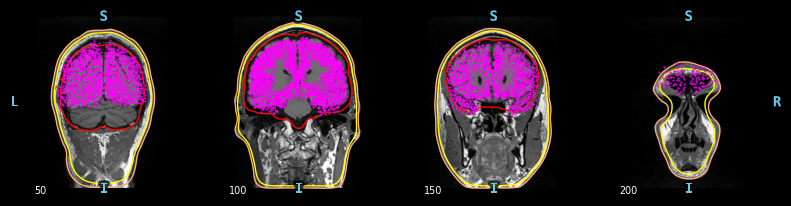

In [ ]:
# Extract parameters - the all config is passed to the function creating_source_space_object
folder = config['paths']['data_folder']
subjects_dir = config['paths']['subjects_dir']
subject_name = config['subject']['subject_name']
spacing = config['source_space']['spacing']
brain_surfaces = config['source_space']['surfaces']
orientation = config['source_space']['orientation']
n_jobs = config['processing']['n_jobs']

print(f"Creating source space for {subject_name}...")
print(f"  Spacing: {spacing}")
print(f"  Surfaces: {brain_surfaces}")

# Change to data directory
os.chdir(folder)

# Create source space
try:
    source_space = creating_source_space_object(config)

    print(f"\n✓ Source space created!")
    print(f"  Left hemisphere: {source_space[0]['nuse']} sources")
    print(f"  Right hemisphere: {source_space[1]['nuse']} sources")
    print(f"  Total: {source_space[0]['nuse'] + source_space[1]['nuse']} sources")
except Exception as e:
    print(f"\n✗ Error: {e}")
    source_space = None

### Step 2: Create Forward Model

Compute the forward solution (leadfield matrix).

In [19]:
# Forward model parameters
conductivity = tuple(config['forward_model']['conductivity'])
ico = config['forward_model']['ico']
mindist = config['forward_model']['mindist']
surfaces = config['forward_model']['surfaces']
coord_frame = config['forward_model']['coord_frame']
file_name    = config['subject']['file_name']

print(f"Creating forward model...")
print(f"  Conductivity: {conductivity}")
print(f"  BEM decimation: ico-{ico}")
print(f"  Minimum distance: {mindist} mm")

try:
    forward_model = creating_forward_model(
        file_name, folder, subject_name, spacing, conductivity,
        subjects_dir, mindist, n_jobs, ico, surfaces, coord_frame
    )
    print(f"\n✓ Forward model created!")
    print(f"  Number of channels: {forward_model['info']['nchan']}")
    print(f"  Number of sources: {forward_model['nsource']}")
except Exception as e:
    print(f"\n✗ Error: {e}")
    forward_model = None

Creating forward model...
  Conductivity: (0.3,)
  BEM decimation: ico-5
  Minimum distance: 5.0 mm
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read
Opening raw data file /Users/administrator/__PC_HSE/Results/Yulia K/Data/meg/S1/sub-001_main2_cleaned2-raw.fif...
    Range : 168000 ... 1809999 =    168.000 ...  1809.999 secs
Ready.
Opening raw data file /Users/administrator/__PC_HSE/Results/Yulia K/Data/meg/S1/sub-001_main2_cleaned2-raw-1.fif...
    Range : 1810000 ... 3155999 =   1810.000 ...  3155.999 secs
Ready.
Creating the BEM geometry...
Going from 5th to 5th subdivision of an icosahedron (n_tri: 20480 -> 20480)
Nearest-neighbor searches will be significantly faster if scikit-learn is installed.
inner skull CM is  -0.70 -25.74  3

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   3 out of   7 | elapsed:    3.3s remaining:    4.4s
[Parallel(n_jobs=7)]: Done   5 out of   7 | elapsed:    3.3s remaining:    1.3s
[Parallel(n_jobs=7)]: Done   7 out of   7 | elapsed:    3.3s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   3 out of   7 | elapsed:    2.6s remaining:    3.5s
[Parallel(n_jobs=7)]: Done   5 out of   7 | elapsed:    2.6s remaining:    1.1s
[Parallel(n_jobs=7)]: Done   7 out of   7 | elapsed:    2.7s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   3 out of   7 | elapsed:    2.6s remaining:    3.5s
[Parallel(n_jobs=7)]: Done   5 out of   7 | elapsed:    2.6s remaining:    1.1s
[Parallel(n_jobs=7)]: Done   7 out of   7 | elapsed:    2.7s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.


Computing MEG at 5115 source locations (free orientations)...


[Parallel(n_jobs=7)]: Done   3 out of   7 | elapsed:    0.2s remaining:    0.3s
[Parallel(n_jobs=7)]: Done   5 out of   7 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=7)]: Done   7 out of   7 | elapsed:    0.2s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   3 out of   7 | elapsed:    0.9s remaining:    1.1s
[Parallel(n_jobs=7)]: Done   5 out of   7 | elapsed:    1.0s remaining:    0.4s
[Parallel(n_jobs=7)]: Done   7 out of   7 | elapsed:    1.1s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.



Finished.
Overwriting existing file.
Overwriting existing file.


[Parallel(n_jobs=7)]: Done   3 out of   7 | elapsed:    0.2s remaining:    0.2s
[Parallel(n_jobs=7)]: Done   5 out of   7 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=7)]: Done   7 out of   7 | elapsed:    0.2s finished


    Write a source space...
    [done]
    Write a source space...
    [done]
    2 source spaces written

✗ Error: Could not load any valid 3D backend
pyvistaqt: No module named 'qtpy'
notebook: No module named 'ipyevents'

 install pyvistaqt, using pip or conda:
'pip install pyvistaqt'
'conda install -c conda-forge pyvistaqt'

 or install ipywidgets, if using a notebook backend
'pip install ipywidgets'
'conda install -c conda-forge ipywidgets'


### Step 3: Compute Source Estimates

Perform source reconstruction using minimum norm estimation.

In [ ]:
# Source estimate parameters
condition_1 = config['conditions']['condition_1']['name']
condition_2 = config['conditions']['condition_2']['name']
condition_3 = config['conditions'].get('baseline', {}).get('name', 'Baseline')
freq_min = config['source_estimate']['freq_min']
freq_max = config['source_estimate']['freq_max']
orient_fix = config['source_estimate']['orientation']
surf_ori = config['source_estimate']['surf_ori']
force_fixed = config['source_estimate']['force_fixed']
reg = config['source_estimate']['reg']
depth = config['source_estimate']['depth']
inversion = config['source_estimate']['method'] #dSPM, MNE

print(f"Computing source estimates...")
print(f"  Method: {inversion}")
print(f"  Frequency: {freq_min}-{freq_max} Hz")
print(f"  Regularization: {reg}")
print(f"  Conditions: {condition_1} vs {condition_2}")

try:
    stc_1, stc_2, stc_baseline, src = creating_source_estimate_object(config)
    
    print(f"\n✓ Source estimates computed!")
    print(f"  {condition_1} shape: {stc_1.data.shape}")
    print(f"  {condition_2} shape: {stc_2.data.shape}")
    print(f"  Time points: {len(stc_1.times)}")
except Exception as e:
    print(f"\n✗ Error: {e}")
    stc_1, stc_2, stc_baseline = None, None, None

Computing source estimates...
  Method: single
  Frequency: 8-12 Hz
  Regularization: 0.05,
  Conditions: SiVe vs CoVe
Opening raw data file /Users/administrator/__PC_HSE/Results/Yulia K/Data/meg/S1/sub-001_main2_cleaned2-raw.fif...
    Range : 168000 ... 1809999 =    168.000 ...  1809.999 secs
Ready.
Opening raw data file /Users/administrator/__PC_HSE/Results/Yulia K/Data/meg/S1/sub-001_main2_cleaned2-raw-1.fif...
    Range : 1810000 ... 3155999 =   1810.000 ...  3155.999 secs
Ready.
Reading forward solution from /Users/administrator/__PC_HSE/Results/Yulia K/Data/meg/S1-ico4-surf-fwd.fif...
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read M

<string>:6: RuntimeWarning: Something went wrong in the data-driven estimation of the data rank as it exceeds the theoretical rank from the info (204 > 70). Consider setting rank to "auto" or setting it explicitly as an integer.
<string>:6: RuntimeWarning: Something went wrong in the data-driven estimation of the data rank as it exceeds the theoretical rank from the info (204 > 70). Consider setting rank to "auto" or setting it explicitly as an integer.
<string>:6: RuntimeWarning: Something went wrong in the data-driven estimation of the data rank as it exceeds the theoretical rank from the info (204 > 70). Consider setting rank to "auto" or setting it explicitly as an integer.


Identifying common channels ...
Computing inverse operator with 204 channels.
    204 out of 204 channels remain after picking
Selected 204 channels
Creating the depth weighting matrix...
Whitening the forward solution.
Computing rank from covariance with rank=None
    Using tolerance 4.5e+08 (2.2e-16 eps * 204 dim * 1e+22  max singular value)
    Estimated rank (grad): 204
    GRAD: rank 204 computed from 204 data channels with 0 projectors
    Setting small GRAD eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing rank from covariance with rank=None
    Using tolerance 1.9e-14 (2.2e-16 eps * 204 dim * 0.41  max singular value)
    Estimated rank (grad): 144
    GRAD: rank 144 computed from 204 data channels with 0 projectors
Computing DICS spatial filters...
Computing beamformer filters for 5115 sources


<string>:1: RuntimeWarning: Something went wrong in the data-driven estimation of the data rank as it exceeds the theoretical rank from the info (204 > 70). Consider setting rank to "auto" or setting it explicitly as an integer.
<string>:1: RuntimeWarning: Something went wrong in the data-driven estimation of the data rank as it exceeds the theoretical rank from the info (204 > 70). Consider setting rank to "auto" or setting it explicitly as an integer.
<string>:1: RuntimeWarning: Something went wrong in the data-driven estimation of the data rank as it exceeds the theoretical rank from the info (204 > 70). Consider setting rank to "auto" or setting it explicitly as an integer.
<string>:1: RuntimeWarning: Something went wrong in the data-driven estimation of the data rank as it exceeds the theoretical rank from the info (144 > 70). Consider setting rank to "auto" or setting it explicitly as an integer.


Filter computation complete
Identifying common channels ...
Computing inverse operator with 204 channels.
    204 out of 204 channels remain after picking
Selected 204 channels
Creating the depth weighting matrix...
Whitening the forward solution.
Computing rank from covariance with rank='info'
    GRAD: rank 70 after 0 projectors applied to 204 channels
    Setting small GRAD eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing rank from covariance with rank='info'
    GRAD: rank 70 after 0 projectors applied to 204 channels
Computing DICS spatial filters...
Computing beamformer filters for 5115 sources
Filter computation complete
Identifying common channels ...
Computing inverse operator with 204 channels.
    204 out of 204 channels remain after picking
Selected 204 channels
Creating the depth weighting matrix...
Whitening the forward solution.
Computing rank from covariance with rank=None
    Using tolerance 4.5e+08 (

/Users/administrator/__PC_HSE/Results/Nikita Otstavnov/SpatialTemporalWorkingMemoryMEG-main/STWM_functions_core.py:214: RuntimeWarning: Something went wrong in the data-driven estimation of the data rank as it exceeds the theoretical rank from the info (204 > 70). Consider setting rank to "auto" or setting it explicitly as an integer.
  csd_2               = csd_2.pick_channels(info['ch_names'], ordered=True)
/Users/administrator/__PC_HSE/Results/Nikita Otstavnov/SpatialTemporalWorkingMemoryMEG-main/STWM_functions_core.py:214: RuntimeWarning: Something went wrong in the data-driven estimation of the data rank as it exceeds the theoretical rank from the info (204 > 70). Consider setting rank to "auto" or setting it explicitly as an integer.
  csd_2               = csd_2.pick_channels(info['ch_names'], ordered=True)
/Users/administrator/__PC_HSE/Results/Nikita Otstavnov/SpatialTemporalWorkingMemoryMEG-main/STWM_functions_core.py:214: RuntimeWarning: Something went wrong in the data-drive

Creating the source covariance matrix
Adjusting source covariance matrix.
Computing rank from covariance with rank=None
    Using tolerance 1.9e-14 (2.2e-16 eps * 204 dim * 0.41  max singular value)
    Estimated rank (grad): 144
    GRAD: rank 144 computed from 204 data channels with 0 projectors
Computing DICS spatial filters...
Computing beamformer filters for 5115 sources


/Users/administrator/__PC_HSE/Results/Nikita Otstavnov/SpatialTemporalWorkingMemoryMEG-main/STWM_functions_core.py:214: RuntimeWarning: Something went wrong in the data-driven estimation of the data rank as it exceeds the theoretical rank from the info (144 > 70). Consider setting rank to "auto" or setting it explicitly as an integer.
  csd_2               = csd_2.pick_channels(info['ch_names'], ordered=True)


Filter computation complete
<Beamformer | DICS, subject "S1", 5115 vert, 204 ch, single inversion>
Computing DICS source power...
[done]
Computing DICS source power...
[done]
Computing DICS source power...
[done]
Writing STC to disk...
[done]
Writing STC to disk...
[done]
Writing STC to disk...
[done]

✓ Source estimates computed!
  SiVe shape: (5115, 1)
  CoVe shape: (5115, 1)
  Time points: 1


### Step 4: Visualize Source Estimates

Display source activation on the cortical surface.

In [21]:
# Visualization parameters
hemi = config['visualization']['hemi']
surface = config['visualization']['surface']
views = config['visualization']['views']

if stc_1 is not None:
    print(f"Visualizing {condition_1} source estimate...")
    
    try:
        brain = source_estimate_visualization(
            stc_1, subject_name, freq_min, freq_max, spacing,
            hemi, 'auto', 'auto', 0.5, 'auto',
            views, 1.0, 'vertical', surface,
            'aparc.a2009s', 'rgb', subjects_dir, 'auto', condition_1
        )
        
        print(f"✓ Visualization displayed!")
        print(f"  Surface: {surface}")
        print(f"  Views: {views}")
        
        # Save image
        output_img = os.path.join(folder, 
                                 f'{subject_name}_{freq_min}-{freq_max}Hz_{condition_1}.png')
        brain.save_image(output_img)
        print(f"  Image saved: {os.path.basename(output_img)}")
    except Exception as e:
        print(f"✗ Visualization error: {e}")
else:
    print("⚠ No source estimate to visualize. Run Step 3 first.")

Visualizing SiVe source estimate...
    Reading a source space...


    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read
Using pyvistaqt 3d backend.
Using control points [2.70711843e-23 3.02279934e-23 3.72811524e-23]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
✓ Visualization displayed!
  Surface: inflated
  Views: ['dorsal', 'lateral', 'medial', 'ventral']
  Image saved: S1_8-12Hz_SiVe.png


### Step 5: Morph to fsaverage Brain

Transform individual source estimates to the standard brain for group analysis.

In [ ]:
print(f"Morphing to fsaverage brain...")

try:
    stc_1_morph, stc_2_morph, stc_baseline_morph, src_subj, src_avg = \
        source_estimate_morphing_to_average(
            folder, subject_name, spacing, freq_min, freq_max,
            orient_fix, condition_1, condition_2, condition_3, subjects_dir
        )
    
    print(f"\n✓ Morphing complete!")
    print(f"  Origin brain: {subject_name}")
    print(f"  Target brain: fsaverage")
    print(f"  Morphed shape: {stc_1_morph.data.shape}")
    
    # Compute and visualize contrast
    print(f"\nComputing contrast: ({condition_1} - {condition_2}) / {condition_3}")
    stc_contrast = (stc_1_morph - stc_2_morph) / stc_baseline_morph
    
    brain_avg = source_estimate_visualization_morph(
        stc_contrast, subject_name, freq_min, freq_max, spacing,
        hemi, 'auto', 'auto', 0.5, 'auto',
        views, 1.0, 'vertical', surface,
        'aparc.a2009s', 'rgb', subjects_dir, 'auto', 'Contrast'
    )
    
    output_contrast = os.path.join(folder,
                                  f'{subject_name}_contrast_{freq_min}-{freq_max}Hz.png')
    brain_avg.save_image(output_contrast)
    print(f"✓ Contrast visualization saved: {os.path.basename(output_contrast)}")
    
except Exception as e:
    print(f"✗ Error: {e}")
    stc_1_morph, stc_2_morph = None, None

---
## Example 3: Batch Processing Multiple Subjects

Process multiple subjects in sequence.

In [ ]:
def example_batch_source_analysis():
    """
    Example: Batch process multiple subjects
    """
    print("="*70)
    print("Example 3: Batch Processing - Source Analysis")
    print("="*70 + "\n")
    
    # Define subjects to process
    subjects = [
        {'name': 'S1', 'file': 'S1_preprocessed-raw.fif'},
        {'name': 'S2', 'file': 'S2_preprocessed-raw.fif'},
        {'name': 'S3', 'file': 'S3_preprocessed-raw.fif'},
    ]
    
    results = []
    
    for subj in subjects:
        print(f"\n{'='*70}")
        print(f"Processing: {subj['name']}")
        print(f"{'='*70}")
        
        # Update configuration
        config['subject']['name'] = subj['name']
        config['subject']['file_name'] = subj['file']
        
        try:
            run_source_analysis(config)
            results.append({'subject': subj['name'], 'status': 'success'})
            print(f"✓ {subj['name']} completed successfully")
        except Exception as e:
            results.append({'subject': subj['name'], 'status': 'failed', 'error': str(e)})
            print(f"✗ {subj['name']} failed: {e}")
    
    # Summary
    print(f"\n{'='*70}")
    print("Batch Processing Summary")
    print(f"{'='*70}")
    for res in results:
        status_symbol = '✓' if res['status'] == 'success' else '✗'
        print(f"{status_symbol} {res['subject']}: {res['status']}")
    
    return results

# Uncomment to run batch processing
# results = example_batch_source_analysis()

---
## Example 4: Group-Level Source Statistics

Perform statistical analysis across multiple subjects using cluster-based permutation tests.

### Step 1: Merge Source Estimates Across Subjects

Collect all morphed source estimates for group analysis.

In [ ]:
# Group statistics parameters
num_subject = config['statistics']['num_subjects']
freq_min = config['source_estimate']['freq_min']
freq_max = config['source_estimate']['freq_max']
spacing = config['source_space']['spacing']
condition_1 = config['conditions']['condition_1']['name']
condition_2 = config['conditions']['condition_2']['name']
condition_3 = config['conditions'].get('baseline', {}).get('name', 'Baseline')

print(f"Merging source estimates for group analysis...")
print(f"  Number of subjects: {num_subject}")
print(f"  Conditions: {condition_1}, {condition_2}, {condition_3}")
print(f"  Frequency: {freq_min}-{freq_max} Hz")

try:
    stc_s, stc_t, stc_a = stc_merger(
        folder, num_subject, subject_name, 
        freq_min, freq_max, orientation,
        condition_1, condition_2, condition_3,
        subjects_dir, spacing
    )
    
    print(f"\n✓ Source estimates merged!")
    print(f"  {condition_1}: {len(stc_s)} subjects")
    print(f"  {condition_2}: {len(stc_t)} subjects")
    print(f"  {condition_3}: {len(stc_a)} subjects")
    print(f"  Data shape per subject: {stc_s[0].data.shape}")
except Exception as e:
    print(f"✗ Error merging source estimates: {e}")
    stc_s, stc_t, stc_a = None, None, None

### Step 2: Visual Check of Group Averages

Inspect average source estimates before running statistics.

In [ ]:
# Visualization parameters for group averages
subject_to_visualize = 0  # Index of subject to use for visualization

if stc_s is not None:
    print(f"Visualizing group average source estimates...")
    
    try:
        source_estimate_average_visual_checher(
            stc_s, stc_t, stc_a,
            subject_to_visualize, freq_min, freq_max, spacing,
            hemi, 'auto', 'auto', 0.5, 'auto',
            views, 1.0, 'vertical', surface,
            'aparc.a2009s', 'rgb', subjects_dir, 'auto'
        )
        print(f"✓ Group average visualization displayed")
    except Exception as e:
        print(f"✗ Visualization error: {e}")
else:
    print("⚠ No merged source estimates. Run Step 1 first.")

### Step 3: Cluster-Based Permutation Statistics

Perform statistical inference using cluster-based permutation testing.

In [ ]:
# Statistical parameters
p_threshold = config['statistics']['p_threshold']
n_permutations = config['statistics']['n_permutations']
tstep = config['statistics']['tstep']
n_jobs = config['processing']['n_jobs']
alpha_level = config['statistics']['alpha_level']

print(f"Running cluster-based permutation test...")
print(f"  Cluster threshold: p < {p_threshold}")
print(f"  Number of permutations: {n_permutations}")
print(f"  Alpha level: {alpha_level}")
print(f"\n⏳ This may take several minutes...\n")

if stc_s is not None and stc_t is not None:
    try:
        stc_all_cluster_vis, stc_new, clu = statistical_inference(
            num_subject, stc_s, stc_t, stc_a,
            spacing, folder, subjects_dir,
            p_threshold, n_permutations, tstep,
            n_jobs, 'indices', None, alpha_level
        )
        
        print(f"\n✓ Statistical inference complete!")
        print(f"  Number of clusters found: {len(clu)}")
        
        # Display significant clusters
        if len(clu) > 0:
            print(f"\n  Significant clusters (p < {alpha_level}):")
            for i, cluster_info in enumerate(clu):
                if cluster_info[1] < alpha_level:
                    print(f"    Cluster {i+1}: p = {cluster_info[1]:.4f}")
        else:
            print(f"  No significant clusters found.")
            
    except Exception as e:
        print(f"✗ Statistical inference error: {e}")
        stc_all_cluster_vis, clu = None, None
else:
    print("⚠ No source estimates available. Run Step 1 first.")
    stc_all_cluster_vis, clu = None, None

### Step 4: Visualize Statistical Results

Display significant clusters on the cortical surface.

In [ ]:
if stc_all_cluster_vis is not None and clu is not None:
    print(f"Visualizing significant clusters...")
    
    try:
        brain_stats = stat_visualization(
            stc_all_cluster_vis, freq_min, freq_max, spacing,
            hemi, 'auto', 'auto', 0.5, 'auto',
            views, 1.0, 'vertical', surface,
            'aparc.a2009s', 'rgb', subjects_dir, 'auto'
        )
        
        # Save statistical map
        stats_img = os.path.join(folder, 
                                f'group_stats_{freq_min}-{freq_max}Hz_clusters.png')
        brain_stats.save_image(stats_img)
        print(f"✓ Statistical map saved: {os.path.basename(stats_img)}")
        
    except Exception as e:
        print(f"✗ Visualization error: {e}")
else:
    print("⚠ No statistical results to visualize. Run Step 3 first.")

---
## Example 5: Multi-Frequency Band Analysis

Analyze multiple frequency bands in a single workflow.

In [ ]:
def example_multiband_analysis():
    """
    Example: Analyze multiple frequency bands
    """
    print("="*70)
    print("Example 5: Multi-Frequency Band Analysis")
    print("="*70 + "\n")
    
    # Define frequency bands of interest
    freq_bands = {
        'delta': (1, 4),
        'theta': (4, 8),
        'alpha': (8, 12),
        'beta': (12, 30),
        'low_gamma': (30, 50),
        'high_gamma': (50, 80)
    }
    
    results = {}
    
    for band_name, (fmin, fmax) in freq_bands.items():
        print(f"\n{'-'*70}")
        print(f"Processing {band_name.upper()} band: {fmin}-{fmax} Hz")
        print(f"{'-'*70}")
        
        # Update frequency configuration
        config['source_estimate']['freq_min'] = fmin
        config['source_estimate']['freq_max'] = fmax
        
        try:
            # Run source analysis for this band
            run_source_analysis(config)
            results[band_name] = 'success'
            print(f"✓ {band_name} band completed")
        except Exception as e:
            results[band_name] = f'failed: {e}'
            print(f"✗ {band_name} band failed: {e}")
    
    # Summary
    print(f"\n{'='*70}")
    print("Multi-Band Analysis Summary")
    print(f"{'='*70}")
    for band, status in results.items():
        symbol = '✓' if status == 'success' else '✗'
        print(f"{symbol} {band}: {status}")
    
    return results

# Uncomment to run multi-band analysis
# results = example_multiband_analysis()

---
## Advanced: Custom Visualization

Create custom visualizations of source space results.

In [ ]:
def plot_source_timecourse(stc, vertices_idx, title='Source Time Course'):
    """
    Plot time course for specific vertices.
    
    Parameters
    ----------
    stc : SourceEstimate
        Source estimate object
    vertices_idx : list
        Indices of vertices to plot
    title : str
        Plot title
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for idx in vertices_idx:
        if idx < stc.data.shape[0]:
            ax.plot(stc.times, stc.data[idx, :], label=f'Vertex {idx}', linewidth=2)
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Activation (a.u.)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return fig

# Example usage (if stc_1 exists)
if 'stc_1' in globals() and stc_1 is not None:
    # Plot time course for first 5 vertices
    fig = plot_source_timecourse(stc_1, [0, 100, 200, 300, 400], 
                                 f'{condition_1} - Time Course')
else:
    print("⚠ No source estimate available. Run source analysis first.")

In [ ]:
def plot_source_spectrum(stc, vertex_idx=0, title='Source Spectrum'):
    """
    Plot frequency spectrum of source activation.
    
    Parameters
    ----------
    stc : SourceEstimate
        Source estimate object
    vertex_idx : int
        Vertex index to analyze
    title : str
        Plot title
    """
    from scipy import signal
    
    if vertex_idx >= stc.data.shape[0]:
        print(f"⚠ Vertex {vertex_idx} out of range. Using vertex 0.")
        vertex_idx = 0
    
    # Compute power spectrum
    sfreq = 1.0 / (stc.times[1] - stc.times[0])  # Sampling frequency
    freqs, psd = signal.welch(stc.data[vertex_idx, :], sfreq, nperseg=256)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.semilogy(freqs, psd, linewidth=2)
    ax.set_xlabel('Frequency (Hz)', fontsize=12)
    ax.set_ylabel('Power', fontsize=12)
    ax.set_title(f'{title} - Vertex {vertex_idx}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 100])
    plt.tight_layout()
    plt.show()
    
    return fig

# Example usage
if 'stc_1' in globals() and stc_1 is not None:
    fig = plot_source_spectrum(stc_1, vertex_idx=100,
                               title=f'{condition_1} - Power Spectrum')

---
## Summary and Key Points

This notebook demonstrated:

✅ **Source space creation** - Building cortical source models  
✅ **Forward modeling** - Computing leadfield matrices  
✅ **Source estimation** - Reconstructing cortical activity  
✅ **Morphing** - Transforming to standard brain  
✅ **Group statistics** - Cluster-based permutation testing  
✅ **Batch processing** - Analyzing multiple subjects and frequency bands  
✅ **Visualization** - Displaying results on cortical surfaces  

### Key Parameters to Adjust

**Source Space:**
- `spacing`: ico4 (fast), ico5 (detailed), oct6 (octahedral)
- Higher decimation = more sources = slower but more detailed

**Forward Model:**
- `conductivity`: Brain tissue conductivity (typically 0.3 S/m)
- `mindist`: Minimum distance from skull (avoid edge effects)

**Source Estimation:**
- `method`: 'MNE' (minimum norm), 'dSPM' (noise-normalized), 'sLORETA' (low-resolution)
- `reg`: Regularization (lower = noisier, higher = smoother)
- `depth`: Depth weighting (compensates for depth bias)

**Statistics:**
- `p_threshold`: Cluster-forming threshold
- `n_permutations`: More permutations = more accurate p-values
- `alpha_level`: Significance level for reporting

### Common Issues and Solutions

**Issue:** Coregistration fails  
**Solution:** Check that fiducials are correctly marked, use more head shape points

**Issue:** Forward solution has NaN values  
**Solution:** Increase `mindist`, check BEM surfaces

**Issue:** No significant clusters found  
**Solution:** Lower `p_threshold`, increase `n_permutations`, check data quality

**Issue:** Visualization doesn't show activation  
**Solution:** Check time window, adjust color scale limits

### Next Steps

1. Optimize regularization parameter for your data
2. Try different inverse methods (MNE, dSPM, sLORETA)
3. Perform region of interest (ROI) analysis
4. Explore connectivity in source space
5. Compare results across frequency bands

### Resources

- [MNE Source Estimation Tutorial](https://mne.tools/stable/auto_tutorials/inverse/)
- [FreeSurfer Documentation](https://surfer.nmr.mgh.harvard.edu/)
- [Source Space Statistics](https://mne.tools/stable/auto_tutorials/stats-source-space/)

---
## Interactive Exploration

Use the cells below to explore your source space results interactively.

In [ ]:
# Load and explore your source estimates
# stc = mne.read_source_estimate('path/to/your/stc')
# 
# # Explore properties
# print(f"Shape: {stc.data.shape}")
# print(f"Time range: {stc.times[0]:.3f} - {stc.times[-1]:.3f} s")
# print(f"Peak activation: {stc.data.max():.2e} at vertex {stc.data.argmax()}")

pass

In [ ]:
# Custom analysis code here
pass